In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: Inaccurancy in the embeddings, since the published experiment processed sites mutation

In [12]:
base_folder_path = "/home/dhuang/work/Ig-fold/nanobody_db/connector_eval/"
output_path = "/home/dhuang/work/Ig-fold/nanobody_db/final_version/figures/"

In [10]:
original_affinity_dict = {
    "1jtpA_3dwtA": 7.4,
    "1op9A_3dwtA": 0.32,
    "3ogoG_3dwtA": 0.32
}

grafted_affinity_dict = {
    "1jtpA_3dwtA": 52.0,
    "1op9A_3dwtA": 7.1,
    "3ogoG_3dwtA": 400.0
}

In [11]:

def extract_embeddings_and_affinity(data_path):
    original_df = pd.read_csv(os.path.join(data_path, 'original_raw_embeddings.tsv'), sep='\t').iloc[:,:2]
    grafted_df = pd.read_csv(os.path.join(data_path, 'grafted_raw_embeddings.tsv'), sep='\t').iloc[:,:2]

    original_df.columns = ['PDB_ID', 'embeddings']
    grafted_df.columns = ['PDB_ID', 'embeddings']

    original_df['class'] = 'original'
    grafted_df['class'] = 'grafted'

    original_df['affinity'] = original_df['PDB_ID'].map(original_affinity_dict)
    grafted_df['affinity'] = grafted_df['PDB_ID'].map(grafted_affinity_dict)

    embeddings_df = pd.concat([original_df,grafted_df], axis=0)

    # Remove NaN values in 'affinity' column
    embeddings_df = embeddings_df.dropna(subset=['affinity'])
    return embeddings_df

In [21]:
# 1jtpA_grafting_alignment_s30_250906/extract_distance/filter_best/
# 1op9A_grafting_alignment_s30_250906/extract_distance/filter_best/
# 3ogoG_grafting_alignment_s30_250906/extract_distance/filter_best/

data_folder_list = [
    "1jtpA_grafting_s30_250906/extract_distance/filter_best/",
    "1op9A_grafting_s30_250906/extract_distance/filter_best/",
    "3ogoG_grafting_s30_250906/extract_distance/filter_best/"
]
full_embeddings_df = None
for target_folder in data_folder_list:
    data_path = os.path.join(base_folder_path, target_folder)
    embeddings_df = extract_embeddings_and_affinity(data_path)
    print(embeddings_df)
    # Concat all embeddings_df into one dataframe
    if full_embeddings_df is not None:
        full_embeddings_df = pd.concat([full_embeddings_df, embeddings_df], axis=0)
    else:
        full_embeddings_df = embeddings_df

# Renumber the index of the full_embeddings_df
full_embeddings_df.reset_index(drop=True, inplace=True)

        PDB_ID  embeddings     class  affinity
0  1jtpA_3dwtA   13.686849  original       7.4
0  1jtpA_3dwtA   11.946467   grafted      52.0
        PDB_ID  embeddings     class  affinity
1  1op9A_3dwtA   21.676553  original      0.32
1  1op9A_3dwtA   14.130830   grafted      7.10
        PDB_ID  embeddings     class  affinity
0  3ogoG_3dwtA   17.911191  original      0.32
1  3ogoG_3dwtA   10.773762   grafted    400.00


In [22]:
print(full_embeddings_df)

        PDB_ID  embeddings     class  affinity
0  1jtpA_3dwtA   13.686849  original      7.40
1  1jtpA_3dwtA   11.946467   grafted     52.00
2  1op9A_3dwtA   21.676553  original      0.32
3  1op9A_3dwtA   14.130830   grafted      7.10
4  3ogoG_3dwtA   17.911191  original      0.32
5  3ogoG_3dwtA   10.773762   grafted    400.00


Text(0, 0.5, 'Affinity')

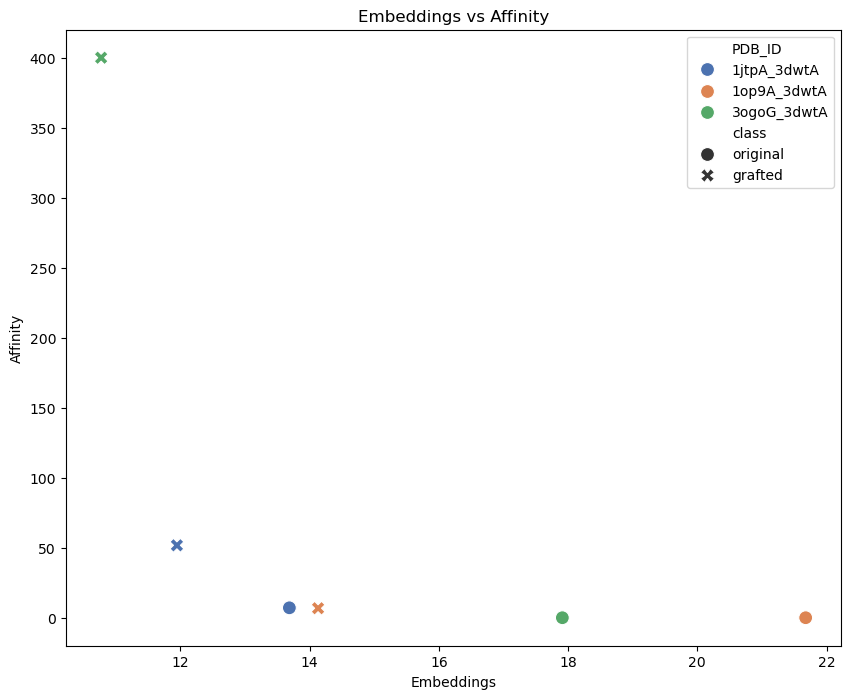

In [24]:
# Plot the scatter plot
# Different shape for different classes
# Different color for different PDB_ID

plt.figure(figsize=(10, 8))
colors = sns.color_palette("deep", n_colors=len(full_embeddings_df['PDB_ID'].unique()))
sns.scatterplot(data=full_embeddings_df, 
                x='embeddings', y='affinity', 
                hue='PDB_ID', 
                style='class', 
                palette=colors,
                s=100)
# Add title and labels
plt.title('Embeddings vs Affinity')
plt.xlabel('Embeddings')
plt.ylabel('Affinity')
